In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv('online_retail_II.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/01/2009 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/01/2009 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/01/2009 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/01/2009 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/01/2009 07:45:00,1.25,13085.0,United Kingdom


In [54]:
df.shape

(525461, 8)

In [55]:
df.describe()

,Quantity,Price,Customer ID
count,525461.000000,525461.000000,417534.000000
mean,10.337667,4.688834,15360.645478
std,107.424110,146.126914,1680.811316
min,-9600.000000,-53594.360000,12346.000000
25%,1.000000,1.250000,13983.000000
50%,3.000000,2.100000,15311.000000
75%,10.000000,4.210000,16799.000000
max,19152.000000,25111.090000,18287.000000


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


In [57]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [58]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(6865)

In [60]:
df = df.drop_duplicates()

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df = df.dropna(subset=['Customer ID'])

In [63]:
df = df.dropna(subset=['Description'])

In [64]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [65]:
# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['Price']

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Latest date
latest_date = df['InvoiceDate'].max()

# Create RFM
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

rfm = rfm.reset_index()

# Remove negative monetary customers
rfm = rfm[rfm['Monetary'] > 0]

print(type(rfm))
print(rfm.head())

<class 'pandas.core.frame.DataFrame'>
   Customer ID  Recency  Frequency  Monetary
1      12347.0        2          2   1323.32
2      12348.0       73          1    222.16
3      12349.0       42          4   2646.99
4      12351.0       10          1    300.93
5      12352.0       10          2    343.80


In [66]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [67]:
rfm = rfm[rfm['Monetary'] > 0]

In [68]:
print("\nRFM Summary:")
print(rfm.describe())


RFM Summary:
        Customer ID      Recency    Frequency      Monetary
count   4283.000000  4283.000000  4283.000000  4.283000e+03
mean   15352.238151    87.529302     5.454588  1.963459e+03
std     1701.244885    95.716440    10.147717  8.593185e+03
min    12347.000000     0.000000     1.000000  8.881784e-16
25%    13883.500000    16.000000     1.000000  3.010900e+02
50%    15358.000000    49.000000     3.000000  6.794400e+02
75%    16834.500000   129.000000     6.000000  1.676590e+03
max    18287.000000   373.000000   270.000000  3.417767e+05


In [69]:
df.shape

(410763, 9)

In [70]:
 x = rfm[['Recency', 'Frequency', 'Monetary']]

In [71]:
# from sklearn.model_selection import train_test_split

# x_train, x_test = train_test_split(x,test_size=0.2,random_state=42)

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)
# x_test_scaled = scaler.transform(x_test)

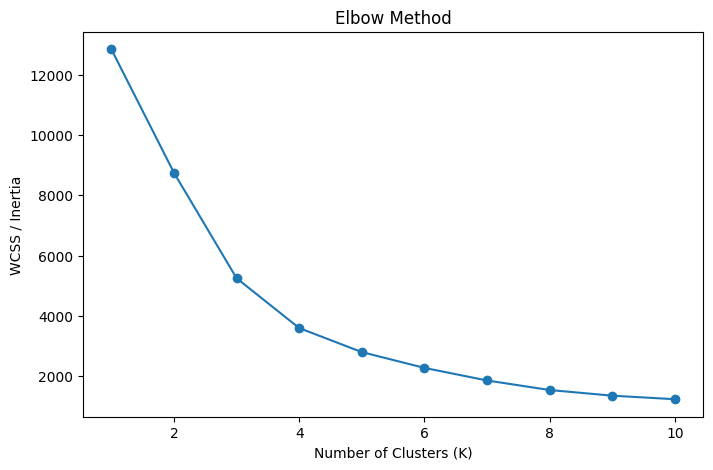

In [73]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)   # use scaled data
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.show()

In [74]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print(rfm['Cluster'].value_counts())

Cluster
1    3208
0    1016
3      54
2       5
Name: count, dtype: int64


In [75]:
type(rfm)

pandas.core.frame.DataFrame

In [77]:
print(rfm.columns)

Index(['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster'], dtype='object')


In [79]:
rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,239.707677,1.934055,512.285614
1,40.777120,5.449813,1673.902870
2,4.600000,139.000000,206935.302000
3,9.425926,59.611111,27489.943944


In [80]:
rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].agg(["mean","min","max","count"])

Recency                   Frequency                      Monetary  \
               mean  min  max count        mean min  max count           mean   
Cluster                                                                         
0        239.707677  136  373  1016    1.934055   1   13  1016     512.285614   
1         40.777120    0  144  3208    5.449813   1   34  3208    1673.902870   
2          4.600000    0    9     5  139.000000  87  270     5  206935.302000   
3          9.425926    0  132    54   59.611111  19  159    54   27489.943944   

                                        
                  min        max count  
Cluster                                 
0        1.776357e-15   30411.26  1016  
1        8.881784e-16   46097.22  3208  
2        1.281724e+05  341776.73     5  
3        1.681400e+03   83760.60    54

In [81]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, rfm["Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.6096731431452919
